In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("smartcart_customers.csv")

In [4]:
#handle missing value
df["Income"] = df["Income"].fillna(df["Income"].median())
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [5]:
#feature Engineering

df["Age"] = 2026-df["Year_Birth"]

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date-df["Dt_Customer"]).dt.days

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [6]:
#Spending 
df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]

In [7]:
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [8]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [9]:
df["Education"] = df["Education"].replace(
    {
        "Basic":"Undergraduate","2n Cycle":"Undergraduate",
        "Graduation":"Graduate",
        "Master":"Postgraduate","PHD":"Postgraduate"
    }
)

df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [10]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone","Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [11]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spend_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols+spend_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [12]:
df_cleaned.shape

(2240, 15)

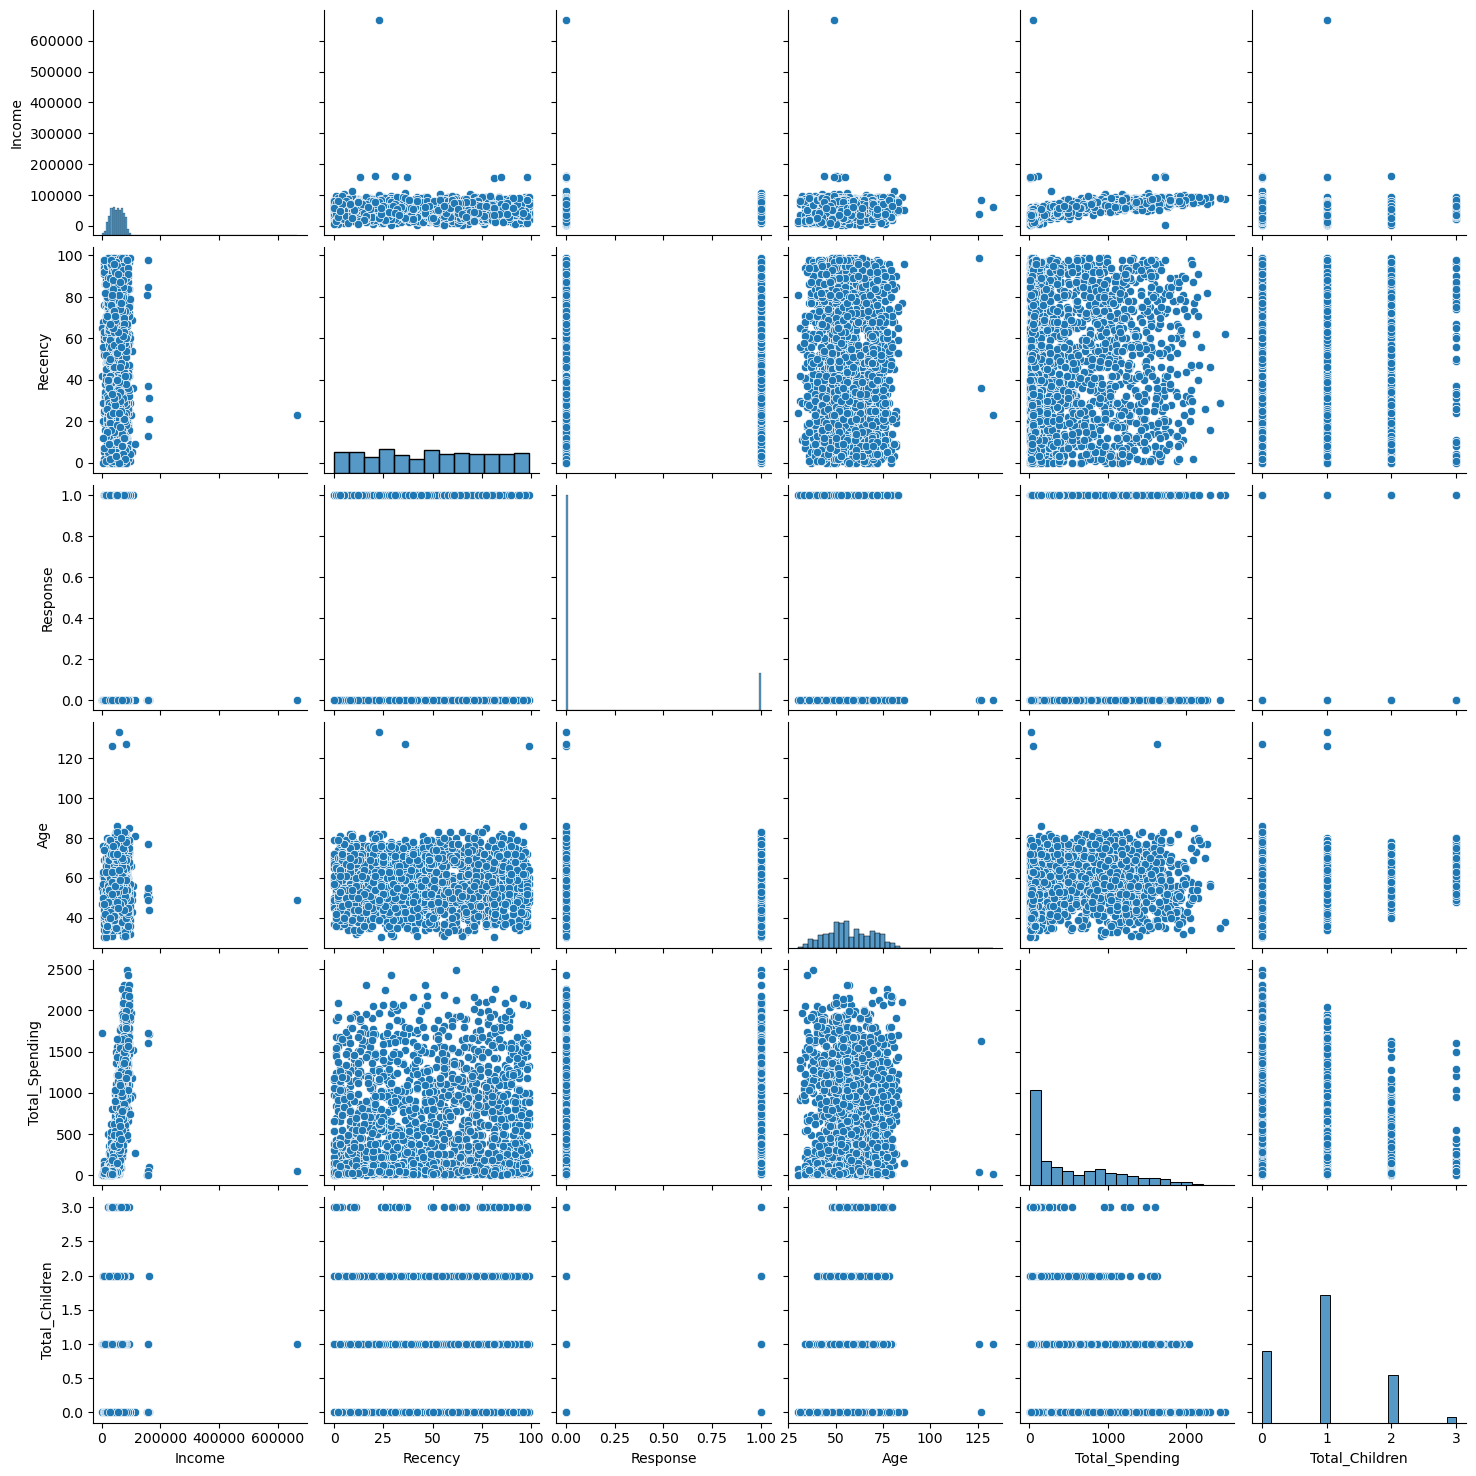

In [13]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [14]:
print("data size with outliers : ",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90 )]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data size without outliers : ",len(df_cleaned))

data size with outliers :  2240
data size without outliers :  2236


<Axes: >

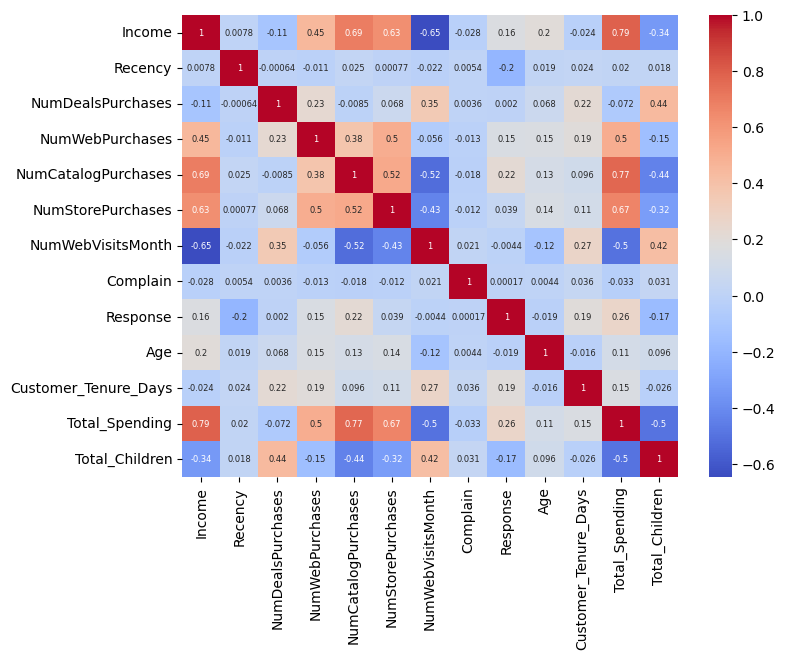

In [15]:
#heatmap

corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [16]:
from sklearn.preprocessing import OneHotEncoder

In [17]:
ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [18]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [19]:
df_encoded= pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_encoded
x_scaled = scaler.fit_transform(X)

In [21]:
x_scaled.shape

(2236, 19)

In [22]:
from sklearn.decomposition import PCA

In [23]:
pca = PCA(n_components=3)

x_pca = pca.fit_transform(x_scaled)

Text(0.5, 0.92, '3D Projection')

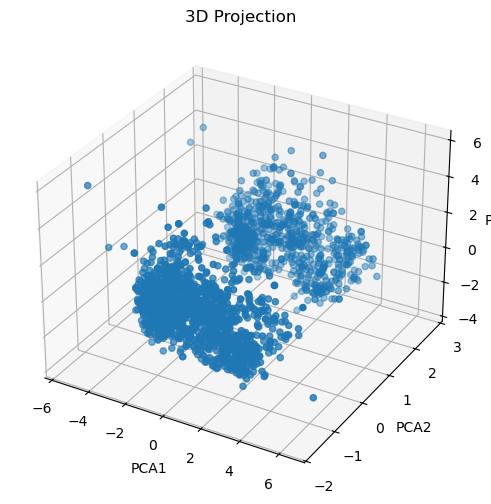

In [24]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [25]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(2,11):
    kmeans =  KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)


ModuleNotFoundError: No module named 'kneed'

In [ ]:
knee = KneeLocator(range(2,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow
print(optimal_k)

In [ ]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(x_pca)
    scores.append(silhouette_score(x_pca,labels))


plt.plot(range(2,11),scores,marker="o")

In [ ]:
k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker='o',color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color="red",linestyle="--")

In [ ]:
kmeans = KMeans(n_clusters=4,random_state=42)
kmeans_labels = kmeans.fit_predict(x_pca)

In [ ]:
fig = plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=kmeans_labels)

In [26]:
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)

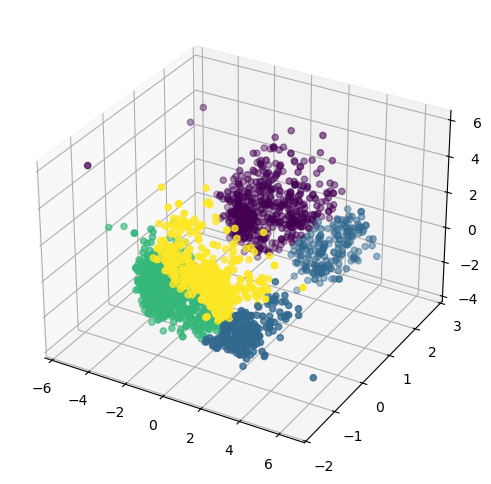

In [27]:
fig = plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

In [39]:
X["cluster"] = labels_agg

In [40]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_PhD,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,0.0,1.0,0.0,0
1,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,1.0,0.0,0.0,0.0,1.0,0.0,0
2,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,1.0,0.0,0.0,0.0,0.0,1.0,3
3,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,1.0,0.0,0.0,0.0,0.0,1.0,2
4,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,0.0,1.0,0.0,0.0,0.0,1.0,3


<Axes: xlabel='cluster', ylabel='count'>

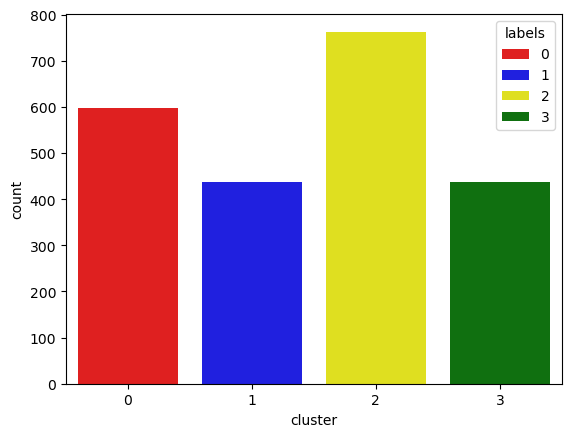

In [41]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue=df_cleaned["labels"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

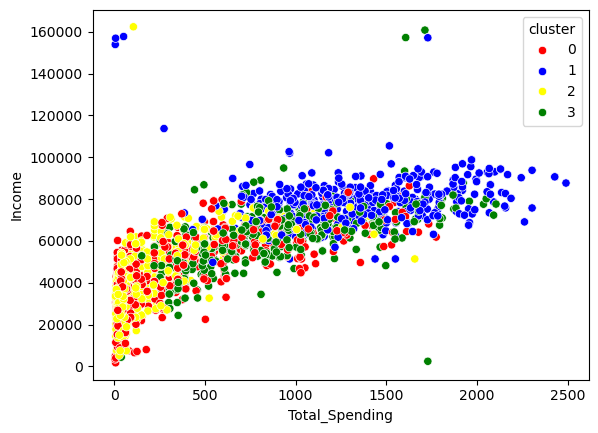

In [42]:
#Income & Spending pattens

sns.scatterplot(x=X["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"],palette=pal)


In [43]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        43568.422241  47.652174           2.690635         3.852843   
1        78564.256849  51.541096           0.981735         4.735160   
2        38349.161861  49.376147           1.901704         2.441678   
3        60504.744851  48.235698           3.915332         6.633867   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.648829           4.842809           6.314381  0.010033   
1                   6.173516           8.609589           2.173516  0.004566   
2                   0.833552           3.777195           6.047182  0.011796   
3                   3.727689           7.803204           5.837529  0.006865   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         